# 난지 특정 하루 입차 · 출차 · 점유 그래프

이 노트는 현재 워크스페이스의 난지 시간별 통합 데이터에서
특정 하루의 시간대별 `추정 입차`, `추정 출차`, `추정 점유 대수`를 그래프로 표현합니다.

주의할 점은 다음과 같습니다.

- `estimated_entries`는 시간대별 추정 입차량입니다.
- `estimated_active_cars`는 해당 시각의 추정 점유 대수입니다.
- `estimated_exits`는 직접 컬럼이 없어서, 아래 식으로 계산한 **추정 출차량**입니다.
- `estimated_exits = estimated_entries - estimated_active_cars_change`

즉 이 노트의 출차 수는 실제 로그가 아니라, 현재 데이터로부터 계산한 2차 추정값입니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
cwd = Path.cwd()
if cwd.name == 'Note' and cwd.parent.name == 'hmw':
    NOTE_DIR = cwd
elif (cwd / 'hmw' / 'Note').exists():
    NOTE_DIR = cwd / 'hmw' / 'Note'
else:
    NOTE_DIR = cwd

dataset_candidates = [
    NOTE_DIR.parent.parent / 'ksm' / 'nanji_hourly_modeling' / 'nanji_hourly_model_dataset_2020_2026.csv',
    NOTE_DIR.parent / 'ksm' / 'nanji_hourly_modeling' / 'nanji_hourly_model_dataset_2020_2026.csv',
    cwd / 'ksm' / 'nanji_hourly_modeling' / 'nanji_hourly_model_dataset_2020_2026.csv',
]
DATASET_PATH = next((path for path in dataset_candidates if path.exists()), dataset_candidates[0])

# 원하는 날짜를 여기서 바꾸면 됩니다.
TARGET_DATE = '2025-01-04'

print('NOTE_DIR:', NOTE_DIR)
print('DATASET_PATH:', DATASET_PATH)
print('TARGET_DATE:', TARGET_DATE)

NOTE_DIR: /Users/electrozone/Documents/nanji_work/hmw/Note
DATASET_PATH: /Users/electrozone/Documents/nanji_work/ksm/nanji_hourly_modeling/nanji_hourly_model_dataset_2020_2026.csv
TARGET_DATE: 2025-01-04


In [3]:
df = pd.read_csv(DATASET_PATH, parse_dates=['datetime'])
daily = df[df['datetime'].dt.date == pd.to_datetime(TARGET_DATE).date()].copy()

if daily.empty:
    raise ValueError(f'No rows found for date: {TARGET_DATE}')

daily['hour'] = daily['datetime'].dt.hour
daily['estimated_exits_raw'] = daily['estimated_entries'] - daily['estimated_active_cars_change']
daily['estimated_exits'] = daily['estimated_exits_raw'].clip(lower=0)
daily = daily.sort_values('datetime').reset_index(drop=True)

daily[['datetime', 'hour', 'estimated_entries', 'estimated_active_cars_change', 'estimated_exits', 'estimated_active_cars', 'avg_stay_minutes']].head(24)

,datetime,hour,estimated_entries,estimated_active_cars_change,estimated_exits,estimated_active_cars,avg_stay_minutes
0,2025-01-04 00:00:00,0,0.000000,0.000000,0.000000,0.000000,54.249064
1,2025-01-04 01:00:00,1,0.000000,0.000000,0.000000,0.000000,54.249064
2,2025-01-04 02:00:00,2,0.000000,0.000000,0.000000,0.000000,54.249064
3,2025-01-04 03:00:00,3,0.000000,0.000000,0.000000,0.000000,54.249064
4,2025-01-04 04:00:00,4,0.000000,0.000000,0.000000,0.000000,54.249064
5,2025-01-04 05:00:00,5,0.000000,0.000000,0.000000,0.000000,54.249064
6,2025-01-04 06:00:00,6,4.336138,3.920524,0.415614,3.920524,54.249064
7,2025-01-04 07:00:00,7,9.761489,4.905337,4.856153,8.825861,54.249064
8,2025-01-04 08:00:00,8,19.494235,8.799873,10.694363,17.625734,54.249064
9,2025-01-04 09:00:00,9,34.692114,13.741178,20.950936,31.366911,54.249064


## 해석용 요약

- `estimated_entries`: 해당 시간에 새로 들어온 차량 수의 추정치
- `estimated_exits`: `입차 - 점유변화`로 계산한 출차 추정치
- `estimated_active_cars`: 해당 시각에 주차장 안에 머물러 있는 차량 수의 추정치
- `avg_stay_minutes`: 그 날짜의 평균 체류 시간(분)

In [4]:
summary_df = pd.DataFrame([
    {'metric': 'daily_estimated_entries_sum', 'value': daily['estimated_entries'].sum()},
    {'metric': 'daily_estimated_exits_sum', 'value': daily['estimated_exits'].sum()},
    {'metric': 'daily_max_active_cars', 'value': daily['estimated_active_cars'].max()},
    {'metric': 'daily_avg_stay_minutes', 'value': daily['avg_stay_minutes'].iloc[0]},
])
summary_df

,metric,value
0,daily_estimated_entries_sum,1068.000000
1,daily_estimated_exits_sum,1065.165446
2,daily_max_active_cars,118.923803
3,daily_avg_stay_minutes,54.249064


/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/1655414378.py:19: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/1655414378.py:19: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/1655414378.py:19: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/1655414378.py:19: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/1655414378.py:19: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/1655414378.py:19: Us

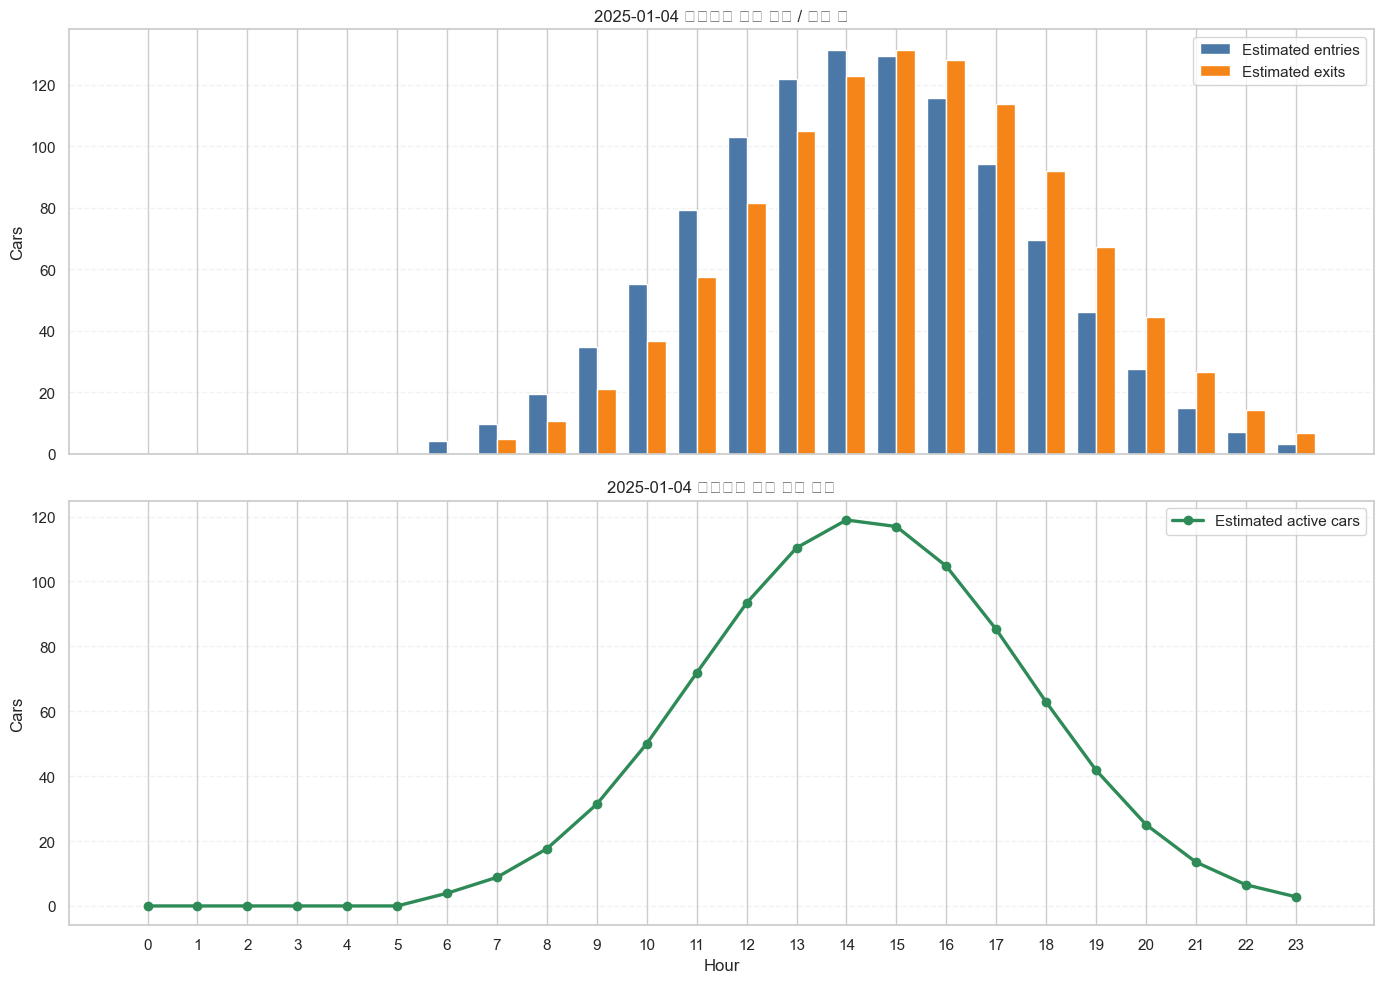

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

bar_width = 0.38
axes[0].bar(daily['hour'] - bar_width / 2, daily['estimated_entries'], width=bar_width, color='#4C78A8', label='Estimated entries')
axes[0].bar(daily['hour'] + bar_width / 2, daily['estimated_exits'], width=bar_width, color='#F58518', label='Estimated exits')
axes[0].set_title(f'{TARGET_DATE} 시간대별 추정 입차 / 출차 수')
axes[0].set_ylabel('Cars')
axes[0].legend(frameon=True)
axes[0].grid(axis='y', alpha=0.25, linestyle='--')

axes[1].plot(daily['hour'], daily['estimated_active_cars'], marker='o', linewidth=2.4, color='#2E8B57', label='Estimated active cars')
axes[1].set_title(f'{TARGET_DATE} 시간대별 추정 점유 대수')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Cars')
axes[1].set_xticks(range(24))
axes[1].legend(frameon=True)
axes[1].grid(axis='y', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/4216787068.py:20: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/4216787068.py:20: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/4216787068.py:20: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/4216787068.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/4216787068.py:20: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kp/6plvck157rg24pz82dxq7qq80000gn/T/ipykernel_59330/4216787068.py:20: User

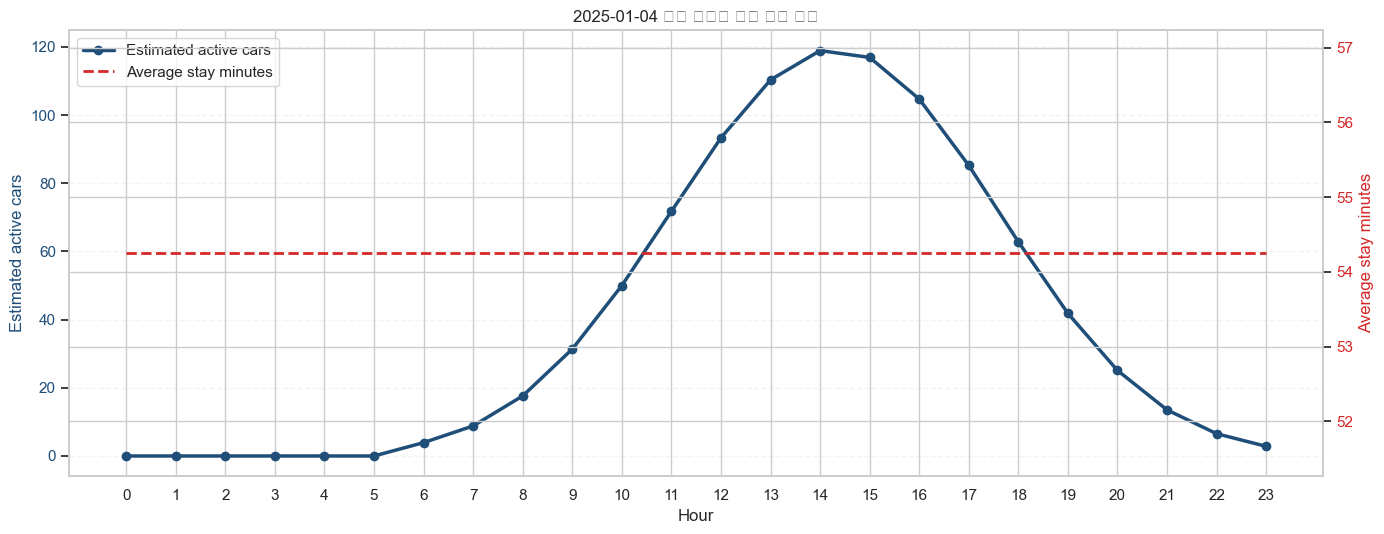

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 5.5))

ax1.plot(daily['hour'], daily['estimated_active_cars'], marker='o', linewidth=2.5, color='#1f4e79', label='Estimated active cars')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Estimated active cars', color='#1f4e79')
ax1.tick_params(axis='y', labelcolor='#1f4e79')
ax1.set_xticks(range(24))
ax1.grid(axis='y', alpha=0.25, linestyle='--')

ax2 = ax1.twinx()
ax2.plot(daily['hour'], daily['avg_stay_minutes'], linewidth=2.0, linestyle='--', color='#d62728', label='Average stay minutes')
ax2.set_ylabel('Average stay minutes', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)
ax1.set_title(f'{TARGET_DATE} 점유 대수와 평균 점유 시간')

plt.tight_layout()
plt.show()

In [7]:
OUTPUT_DIR = NOTE_DIR / 'nanji_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

export_columns = [
    'datetime', 'hour', 'estimated_entries', 'estimated_active_cars_change',
    'estimated_exits', 'estimated_active_cars', 'avg_stay_minutes'
]

export_path = OUTPUT_DIR / f'nanji_car_{TARGET_DATE}.csv'
daily[export_columns].to_csv(export_path, index=False, encoding='utf-8-sig')
print('saved csv:', export_path)

saved csv: /Users/electrozone/Documents/nanji_work/hmw/Note/nanji_outputs/nanji_car_2025-01-04.csv
